# Baboon data

Formålet med denne notebook, er at indlæse datasættet, identificer populationer, beregn heterozygositet, site frequency spectrum (SFS) og forbered subsets til at bruge i de følgende notebooks.
Datasættet består af hele-genomsekvenser fra 225 vilde bavianer fordelt på 6 arter og 19 geografiske lokaliteter (Sørensen et al., 2023).

I denne notebook vil jeg komme ind på følgende:

1. [Indlæs data](#1-indlæs-data)
2. [Udforsk samples og populationer](#2-udforsk-samples-og-populationer)
3. [Udvælg populationer til analyse](#3-udvælg-populationer-til-analyse)
4. [Beregn allele counts per population](#4-beregn-allele-counts-per-population)
5. [Site Frequency Spectrum (SFS)](#5-site-frequency-spectrum-sfs)
6. [Heterozygositet per population](#6-heterozygositet-per-population)
7. [SFS og visualisering](#7-fold-sfs-og-visualisering)
8. [Gem data til efterfølgende notebooks](#8-gem-data-til-efterfølgende-notebooks)

In [1]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph, with_ipv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sgkit as sg
from pathlib import Path
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# Sti til data
DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")

# Output mappe til gemte data
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


## 1. Indlæs data

Jeg indlæser data for kromosom 20.

In [2]:
# Indlæs chr20
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")
print(ds)


<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndar

In [3]:
# Antal varianter og samples
n_variants = ds.dims["variants"]
n_samples  = ds.dims["samples"]
print(f"Antal varianter: {n_variants:,}")
print(f"Antal samples:   {n_samples}")

Antal varianter: 2,665,269
Antal samples:   227


/tmp/ipykernel_3419300/1356574667.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_variants = ds.dims["variants"]
/tmp/ipykernel_3419300/1356574667.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_samples  = ds.dims["samples"]


## 2. Udforsk samples og populationer

Jeg lister alle sample-ID'er og kortlægger dem til arter og lokaliteter.
Sample-ID'erne følger mønsteret `PD_XXXX`. Artsinformation hentes fra en metadata-tabel fra artiklen af Sørensen et al., 2023.

In [6]:
# Liste over alle samples
sample_ids = ds['sample_id'].values
print(f"Første 10 samples: {sample_ids[:10]}")
print(f"Totalt {len(sample_ids)} samples")

Første 10 samples: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']
Totalt 227 samples


In [9]:
# Definer populationer 
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # Art               : [sample IDs]                                                           : Navn
    "yellow_east_mikumi":  ['PD_0268', 'PD_0269','PD_0270', 
                            'PD_0271', 'PD_0272', 'PD_0637',
                            'PD_0687', 'PD_0688','PD_0689', 'PD_0690',
                            'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747',
                            'PD_0748', 'PD_0752', 'PD_0753', 'PD_0754', 
                            'PD_0755','PD_0756', 'PD_0761', 'PD_0762',
                            'PD_0763', 'PD_0764', 'PD_0765','PD_0766',
                            'PD_0767','PD_0768', 'PD_0769','PD_0770',
                            'PD_0771', 'PD_0772', 'PD_0773', 'PD_0774','PD_0775'],               # P. cynocephalus, Mikumi
    "Yellow_east_ruaha":   ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216', 'PD_0217', 'PD_0503'],   # P. cynocephalus, Ruaha
    "yellow_west_mahale":  ['PD_0228','PD_0229','PD_0230', 'PD_0231',
                            'PD_0232','PD_0233','PD_0234', 'PD_0658', 'PD_0659'],                # P. cynocephalus, Mahale/Katavi
    "kinda":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB', 'PD_0692', 'PD_0693', 'PD_0694', 'PD_0695'],          # P. kindae, Chunga/Dendro Park
    "olive_south":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0238', 'PD_0239',
                            'PD_0240', 'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265',
                            'PD_0266','PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 
                            'PD_0496', 'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501',
                            'PD_0502', 'PD_0641', 'PD_0642', 'PD_0674', 'PD_0675', 'PD_0676',
                            'PD_0677', 'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682',
                            'PD_0683', 'PD_0684', 'PD_0685', 'PD_0686'],                         # P. anubis, Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire)
    "olive_gog":           ['PD_0719', 'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724',
                            'PD_0725', 'PD_0726', 'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730',
                            'PD_0731', 'PD_0732', 'PD_0733', 'PD_0734', 'PD_0735', 'PD_0736',
                            'PD_0737', 'PD_0738' 'PD_0739', 'PD_0740', 'PD_0741', 'PD_0742',
                            'PD_0743', 'PD_0744'],                                              # P. anubis, Gog (Ethiopia)
}


In [8]:
# Laver en metadata dataframe
rows = []
for pop, ids in population_map.items():
    for sid in ids:
        rows.append({"sample_id": sid, "population": pop})

meta = pd.DataFrame(rows)
print(meta.groupby("population").size().rename("n_samples"))

population
kinda                 29
olive_gog             25
olive_south           46
yellow_east_mikumi    35
yellow_east_ruaha      6
yellow_west_mahale     9
Name: n_samples, dtype: int64


## 3. Udvælg populationer til analyse

Til de efterfølgende two-island og IM-modeller fokuserer jeg på:
- **Eastern yellow baboons** (Mikumi) — veldefineret population
- **Western yellow baboons** (Mahale/Katavi) — hybrid population
- **Kinda baboons** — tæt relateret til western yellow
- **Southern olive baboons** — genflow med eastern yellow dokumenteret i artiklen

Jeg starter med et parvist subset for two-island modellen.

In [15]:
def extract_population(ds, sample_ids_list):
    """
    Udtrækker et subset af datasættet for en given liste af sample-ID'er.
    """
    mask = ds["sample_id"].isin(sample_ids_list).values
    return ds.isel(samples=mask)


# Eastern yellow baboons
ds_yellow_east = extract_population(ds, population_map["yellow_east_mikumi"])
print(f"Eastern yellow mikumi: {ds_yellow_east.dims['samples']} samples")

# Kinda baboons
ds_kinda = extract_population(ds, population_map["kinda"])
print(f"Kinda: {ds_kinda.dims['samples']} samples")

# olive south
ds_olive_south = extract_population(ds, population_map["olive_south"])
print(f"Olives south: {ds_olive_south.dims['samples']} samples")

#Yellow east ruaha
ds_yellow_east_ruaha = extract_population(ds, population_map["Yellow_east_ruaha"])
print(f"Yellow east ruaha: {ds_yellow_east_ruaha.dims['samples']} samples")

# olive gog
ds_olive_gog = extract_population(ds, population_map["olive_gog"])
print(f"Olive gog: {ds_olive_gog.dims['samples']} samples")

# yellow west mahale
ds_yellow_west_mahale = extract_population(ds, population_map["yellow_west_mahale"])
print(f"Yellow west mahale: {ds_yellow_west_mahale.dims['samples']} samples")

Eastern yellow mikumi: 35 samples
Kinda: 29 samples
Olives south: 46 samples
Yellow east ruaha: 6 samples
Olive gog: 24 samples
Yellow west mahale: 9 samples


/tmp/ipykernel_3419300/3842994244.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Eastern yellow mikumi: {ds_yellow_east.dims['samples']} samples")
/tmp/ipykernel_3419300/3842994244.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Kinda: {ds_kinda.dims['samples']} samples")
/tmp/ipykernel_3419300/3842994244.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f

## 4. Beregn allele counts per population

Jeg beregner derived variant counts (singletons, doubletons, osv.) for hver population.
Disse counts danner grundlaget for SFS analysen og for at fitte coalescent modeller.

In [23]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for hver population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    vac = sg.count_variant_alleles(ds_pop)
    ac  = vac["variant_allele_count"].values  # shape: (variants, alleles)
    
    nr_samples    = ac.sum(axis=1)   # totalt antal haplotyper
    derived_count = ac[:, 1]         # antal kopier af det derived allel
    
    df = pd.DataFrame({
        "position":      ds_pop["variant_position"].values,
        "derived_count": derived_count,
        "nr_samples":    nr_samples,
    })
    
    # Behold kun SNPs med mindst et derived allel
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])]
    
    print(f"{pop_name}: {len(df):,} segregerende SNPs")
    return df


df_yellow_east = compute_derived_counts(ds_yellow_east, "Eastern yellow")
df_kinda = compute_derived_counts(ds_kinda, "Kinda")
df_yellow_west_mahale = compute_derived_counts(ds_yellow_west_mahale,"Yellow West mahale")
df_olive_gog = compute_derived_counts(ds_olive_gog, "Olive gog")
df_Yellow_east_ruaha = compute_derived_counts(ds_yellow_east_ruaha, "Yellow east ruaha")
df_olive_south = compute_derived_counts(ds_olive_south, "Olive south")


Eastern yellow: 868,037 segregerende SNPs
Kinda: 947,644 segregerende SNPs
Yellow West mahale: 771,964 segregerende SNPs
Olive gog: 591,067 segregerende SNPs
Yellow east ruaha: 628,476 segregerende SNPs
Olive south: 764,811 segregerende SNPs


In [24]:
df_yellow_east.head()

,position,derived_count,nr_samples
1,73,7,70
4,149,13,70
7,283,49,70
8,437,5,70
10,471,7,70


In [18]:
df_kinda.head()

,position,derived_count,nr_samples
1,73,16,58
3,148,1,58
5,162,4,58
7,283,8,58
17,654,1,58


In [25]:
df_yellow_west_mahale.head()

,position,derived_count,nr_samples
2,126,1,18
6,236,1,18
7,283,3,18
16,607,1,18
19,732,2,18


In [20]:
df_olive_gog.head() 

,position,derived_count,nr_samples
13,501,2,48
36,1828,5,48
37,1867,2,48
38,1926,5,48
39,1939,5,48


In [21]:
df_Yellow_east_ruaha.head() 

,position,derived_count,nr_samples
4,149,6,12
6,236,3,12
7,283,6,12
30,1349,2,12
31,1379,2,12


In [22]:
df_olive_south.head() 

,position,derived_count,nr_samples
4,149,1,92
6,236,22,92
7,283,10,92
9,450,3,92
27,1045,2,92


## 5. Site Frequency Spectrum (SFS)

SFS tæller, hvor mange SNPs der er observeret med $1$ kopi, $2$ kopier, ..., $n-1$ kopier af det derived allel. Formen af SFS afspejler populationshistorien fx. viser en overvægt af singletons tegn på vækst eller selektion.

Jeg bruger den unfoldede SFS (jeg antager, at allel $1$ er det derived/afledte allel).

In [ ]:
def compute_sfs(df, pop_name="population"):
    """
    Beregner SFS for en population.
    """
    n = int(df["nr_samples"].max())   # haploid sample size
    counts = np.zeros(n + 1, dtype=int)
    
    for k, grp in df.groupby("derived_count"):
        if 0 < k < n:
            counts[k] = len(grp)
    
    sfs = pd.Series(counts[1:n], index=range(1, n), name=pop_name)
    return sfs


sfs_yellow_east = compute_sfs(df_yellow_east, "Eastern yellow")
sfs_kinda = compute_sfs(df_kinda, "Kinda")
sfs_yellow_west_mahale = compute_sfs(df_yellow_west_mahale, "Yellow West mahale")
sfs_olive_gog = compute_sfs(df_olive_gog, "olie_gog")
sfs_Yellow_east_ruaha = compute_sfs(df_Yellow_east_ruaha, "Yellow east ruaha")
sfs_olive_south = compute_sfs(df_olive_south, "Olive south")


In [27]:
print(sfs_yellow_east.head(10))

1     133084
2      82780
3      57377
4      45959
5      39250
6      31387
7      29371
8      24856
9      21101
10     18544
Name: Eastern yellow, dtype: int64


In [28]:
print(sfs_kinda.head(10))

1     157195
2      99268
3      76569
4      60061
5      49327
6      40836
7      35123
8      31786
9      26464
10     23015
Name: Kinda, dtype: int64


In [29]:
print(sfs_yellow_west_mahale.head(10)) 

1     217728
2     127049
3      79500
4      57355
5      45140
6      34297
7      29920
8      23695
9      23087
10     18603
Name: Yellow West mahale, dtype: int64


In [30]:
print(sfs_olive_gog.head(10))

1     131677
2      76698
3      44018
4      34349
5      28137
6      23011
7      18682
8      16028
9      14344
10     12439
Name: olie_gog, dtype: int64


In [31]:
print(sfs_Yellow_east_ruaha.head(10))

1     201805
2     108843
3      69626
4      50216
5      39100
6      34621
7      26202
8      24955
9      21560
10     23533
Name: Yellow east ruaha, dtype: int64


In [32]:
print(sfs_olive_south.head(10)) 

1     135994
2      81407
3      57666
4      42572
5      37741
6      29516
7      25587
8      18859
9      17499
10     15444
Name: Olive south, dtype: int64


## 6. Heterozygositet per population

Gennemsnitlig heterozygositet (π) per base-par er et mål for genetisk diversitet.
Artiklen rapporterer heterozygositet fra 0.0006–0.0029 på tværs af de 19 lokaliteter.

In [33]:
def compute_pi(df):
    """
    Beregner gennemsnitlig nukleotiddiversitet (π) per site.
    π = Σ [ (k/n) * ((n-k)/n) * 2 ] / L
    hvor k = derived count, n = nr haploid samples, L = antal sites.
    """
    k = df["derived_count"].values
    n = df["nr_samples"].values
    
    # Heterozygositet per site (forventet frekvens af het. par)
    het_per_site = 2 * (k / n) * ((n - k) / n)
    
    # Totalt antal sites 
    L = int(df["position"].max() - df["position"].min())
    
    pi = het_per_site.sum() / L
    return pi


pi_vals = {}
for name, df_pop in [
    ("Eastern yellow", df_yellow_east),
    ("Kinda", df_kinda),
    ("Yellow West mahale", df_yellow_west_mahale),
    ("Olive gog", df_olive_gog),
    ("Yellow east ruaha", df_Yellow_east_ruaha),
    ("Olive south", df_olive_south)

]:
    pi_vals[name] = compute_pi(df_pop)

pi_df = pd.DataFrame.from_dict(pi_vals, orient="index", columns=["pi"])
print(pi_df.round(6))

# Forventet: ~ 0.0006–0.0026 jf. artiklen

                          pi
Eastern yellow      0.002584
Kinda               0.002861
Yellow West mahale  0.002868
Olive gog           0.001742
Yellow east ruaha   0.002617
Olive south         0.001969


## 7. SFS og visualisering

Den foldede SFS bruges når jeg ikke er sikre på polariseringen (ancestral vs. derived). Den folder SFS'en ved midten, så jeg kun ser minor allele frequencies. Jeg plotter begge SFS'er for eastern yellow og Kinda baboons.

In [ ]:
def fold_sfs(sfs):
    """
    Folder en unfoldet SFS.
    For n haplotyper: foldet SFS har indeks 1..floor(n/2).
    """
    n = len(sfs) + 1  # antal haplotyper
    mid = n // 2
    folded = sfs.copy().astype(float)
    
    # Fold: summer spejlede bins
    for i in range(1, mid):
        folded.iloc[i - 1] = sfs.iloc[i - 1] + sfs.iloc[n - i - 1]
    
    # Behold kun første halvdel (1..mid)
    return folded.iloc[:mid]


sfs_yellow_east_folded = fold_sfs(sfs_yellow_east)
sfs_kinda_folded       = fold_sfs(sfs_kinda)
sfs_yellow_west_mahale_folded = fold_sfs(sfs_yellow_west_mahale)
sfs_olive_gog_folded = fold_sfs(sfs_olive_gog)
sfs_Yellow_east_ruaha_folded = fold_sfs(sfs_Yellow_east_ruaha)
sfs_olive_south_folded = fold_sfs(sfs_olive_south)


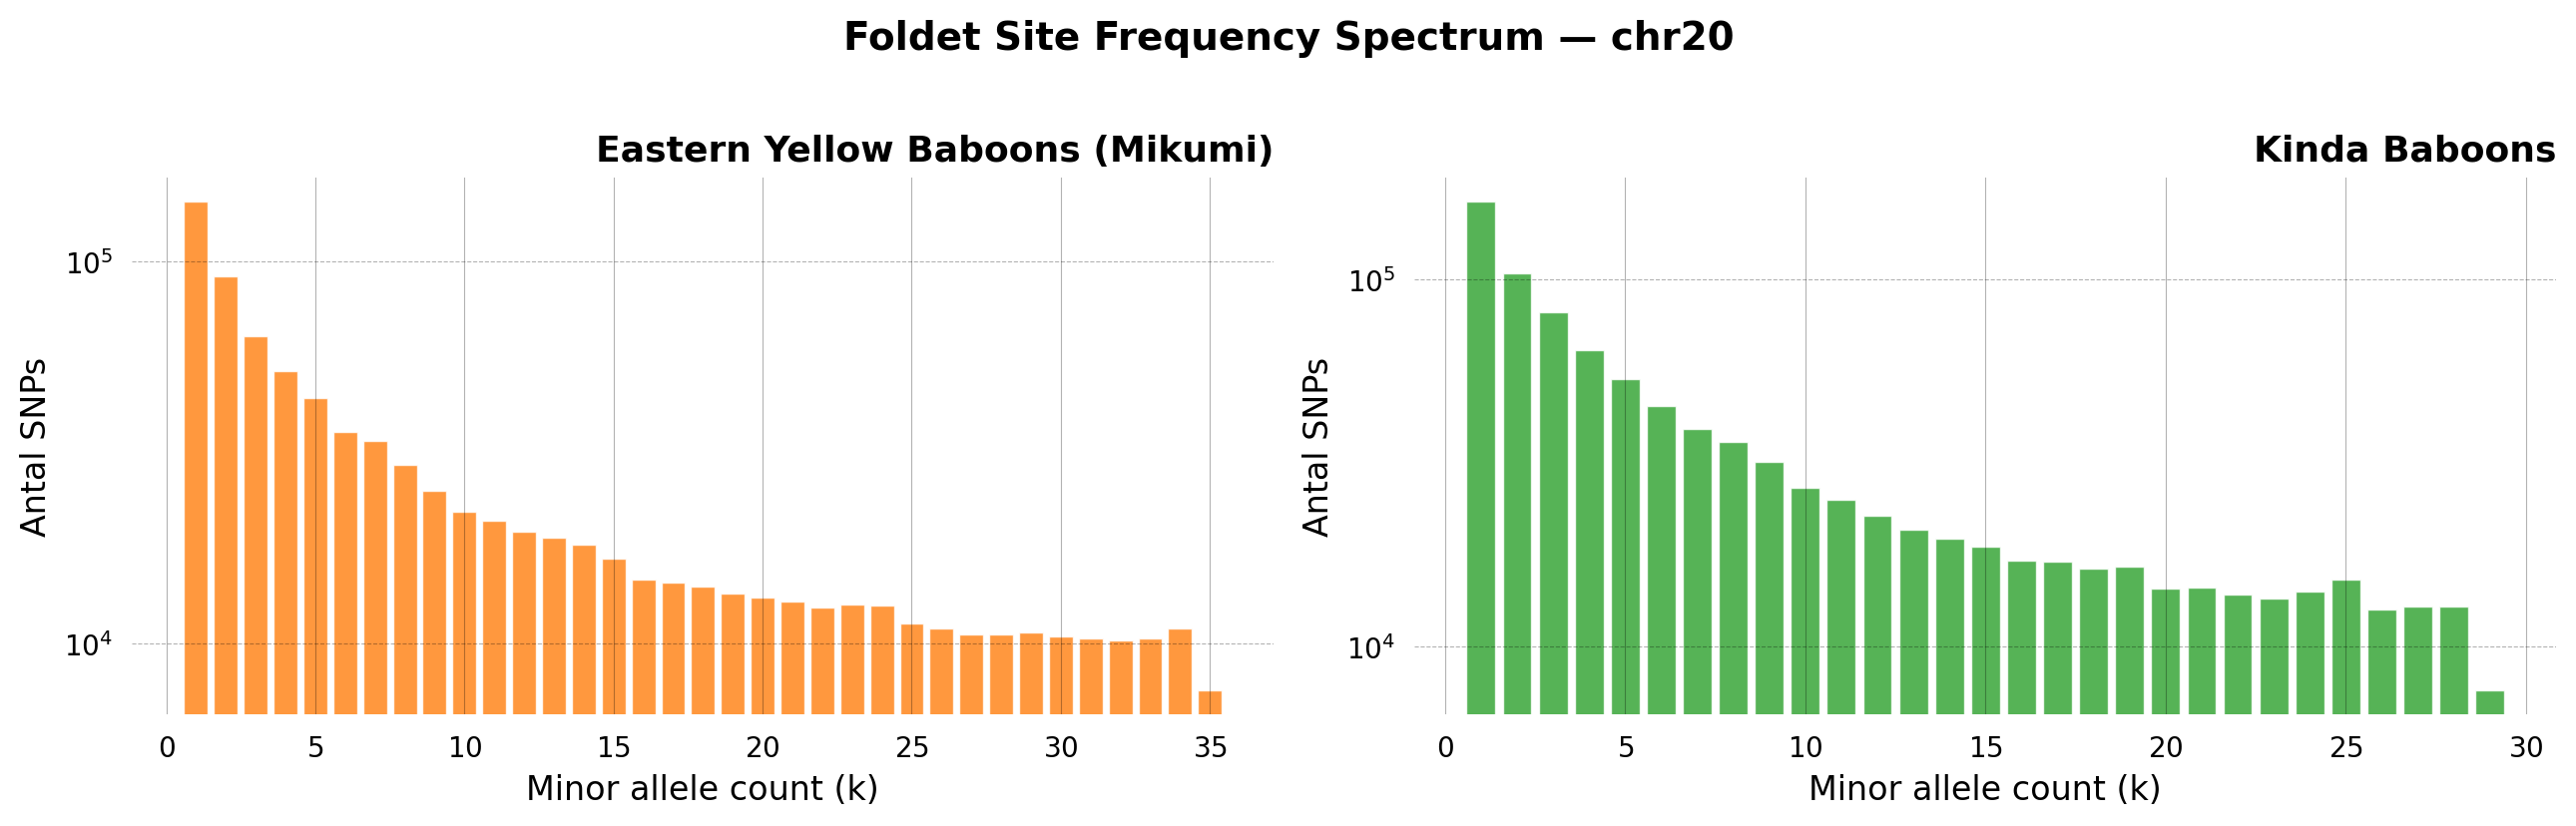

Figur gemt: output/sfs_comparison.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

populations = [
    (sfs_yellow_east_folded, "Eastern Yellow Baboons (Mikumi)", 'C1'),
    (sfs_kinda_folded,       "Kinda Baboons", 'C2'),
]

for ax, (sfs, title, color) in zip(axes, populations):
    freqs = np.arange(1, len(sfs) + 1)
    ax.bar(freqs, sfs.values, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Minor allele count (k)", fontsize=12)
    ax.set_ylabel("Antal SNPs", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Foldet Site Frequency Spectrum — chr20", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "sfs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figur gemt: output/sfs_comparison.png")

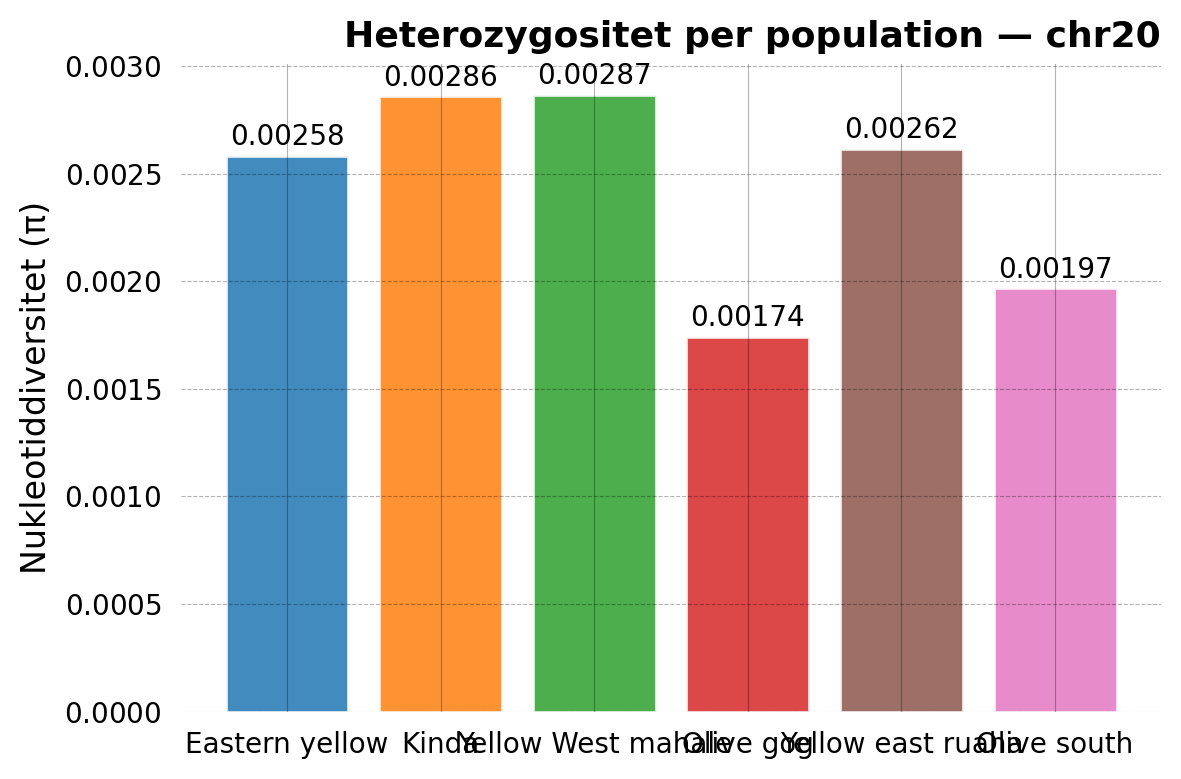

In [59]:
# Sammenligning af heterozygositet
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['C0', 'C1', 'C2', 'C3', 'C5', 'C6']
pops   = list(pi_vals.keys())
vals   = list(pi_vals.values())

bars = ax.bar(pops, vals, color=colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("Nukleotiddiversitet (π)", fontsize=12)
ax.set_title("Heterozygositet per population — chr20", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.00002,
            f"{val:.5f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "heterozygosity.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Gem data til efterfølgende notebooks

Jeg gemmer de beregnede DataFrames som CSV-filer, så Notebook 04 (two-island model) kan indlæse dem direkte uden at genkøre det hele igen.

In [19]:
# Gem derived counts DataFrames
df_yellow_east.to_csv(OUT_DIR / "derived_counts_yellow_east.csv", index=False)
df_kinda.to_csv(OUT_DIR       / "derived_counts_kinda.csv",       index=False)

# Gem foldede SFS'er
sfs_yellow_east_folded.to_csv(OUT_DIR / "sfs_folded_yellow_east.csv", header=True)
sfs_kinda_folded.to_csv(OUT_DIR       / "sfs_folded_kinda.csv",       header=True)

# Gem heterozygositet
pi_df.to_csv(OUT_DIR / "pi_per_population.csv")

print("Alle filer gemt i output/")
for f in sorted(OUT_DIR.iterdir()):
    print(" ", f.name)

Alle filer gemt i output/
  derived_counts_kinda.csv
  derived_counts_yellow_east.csv
  heterozygosity.png
  pi_per_population.csv
  sfs_comparison.png
  sfs_folded_kinda.csv
  sfs_folded_yellow_east.csv


I næste notebook 04 — Two-island model, vil jeg bruge de gemte SFS-data til at fitte en to-populations coalescent-model i phasic der modellerer migration mellem fx. eastern yellow baboons og Kinda baboons.